Hamiltonian / Dissipation Matrix decomposed into Paulis:
SparsePauliOp(['II', 'IX', 'IY', 'IZ', 'XY', 'YX', 'ZI', 'ZX', 'ZY', 'ZZ'],
              coeffs=[-250.  +0.j        ,  250.  +0.j        ,    0.+250.j        ,
 -250.  +0.j        ,    0.+314.15926536j,   -0.-314.15926536j,
 -250.  +0.j        ,  250.  +0.j        ,    0.+250.j        ,
 -250.  +0.j        ])

Average Trotter vs Scipy Fidelity: 0.994952


C:\Users\Aayush\AppData\Local\Temp\ipykernel_26816\3101087097.py:81: RuntimeWarning: overflow encountered in matmul
  state_vector = trotter_step_op @ state_vector
C:\Users\Aayush\AppData\Local\Temp\ipykernel_26816\3101087097.py:81: RuntimeWarning: invalid value encountered in matmul
  state_vector = trotter_step_op @ state_vector


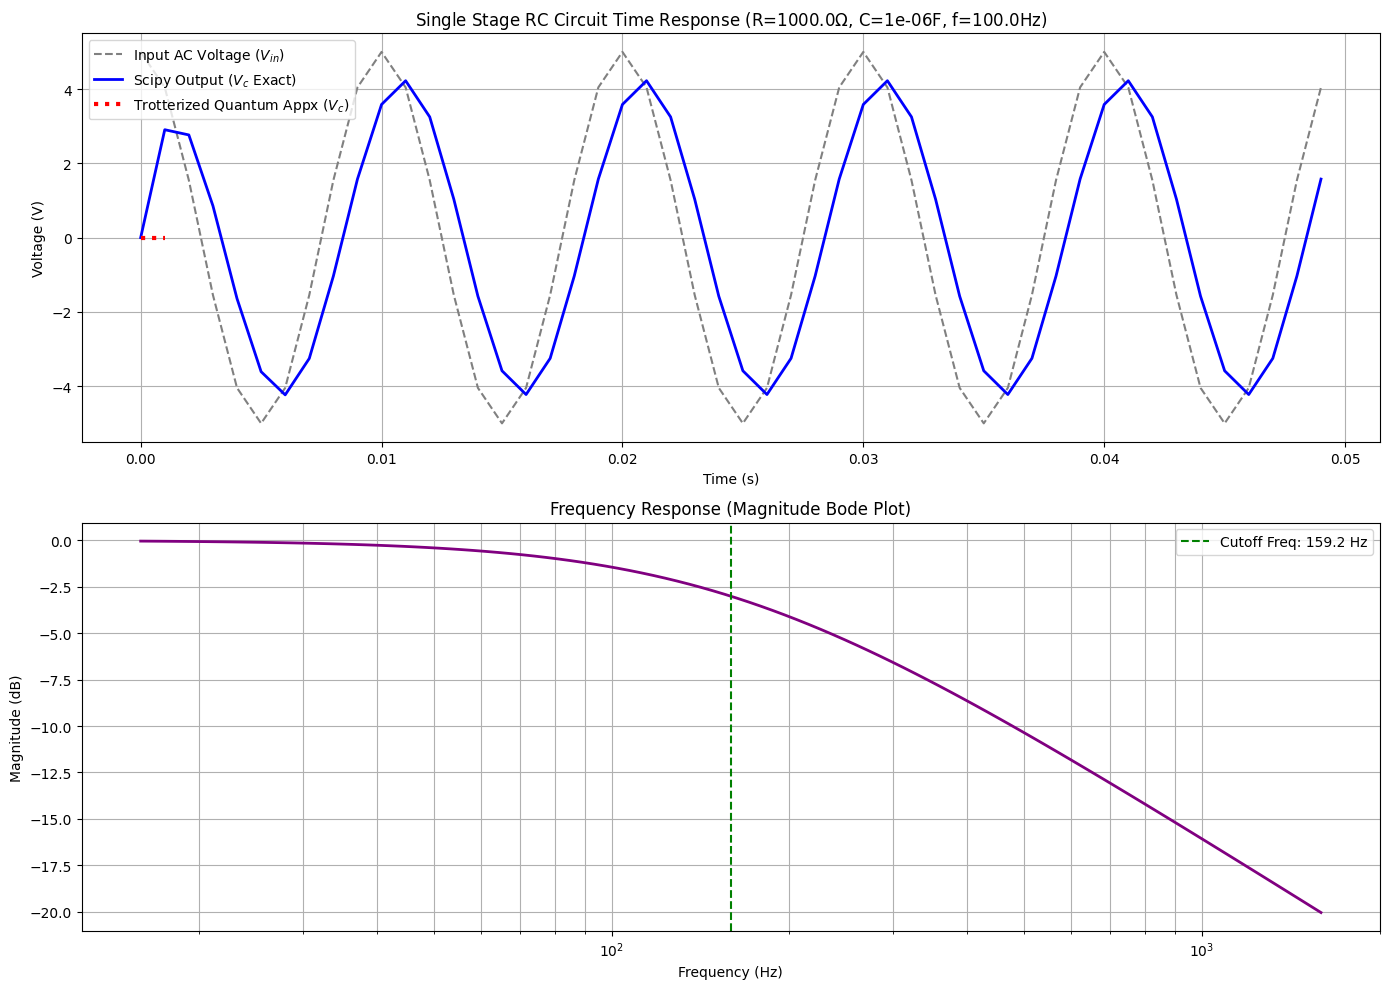

In [3]:
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import scipy.signal as signal
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp, Operator

# ==========================================
# 1. System Parameters
# ==========================================
R = 1000.0       # Resistance in Ohms
C = 1e-6         # Capacitance in Farads
tau = R * C      # Time constant
f = 100.0        # AC Input Frequency in Hz
omega = 2 * np.pi * f
V0 = 5.0         # AC Voltage Amplitude

# Time simulation parameters
t_max = 0.05
dt = 0.001
times = np.arange(0, t_max, dt)

# ==========================================
# 2. Classical Scipy Solution (Ground Truth)
# ==========================================
def rc_deriv(Vc, t):
    Vin = V0 * np.cos(omega * t)
    return (Vin - Vc) / tau

# Initial condition: Vc(0) = 0
Vc_scipy = odeint(rc_deriv, 0.0, times).flatten()
Vin_scipy = V0 * np.cos(omega * times)

# ==========================================
# 3. Quantum Mapping & Pauli Decomposition
# ==========================================
# We map the ODE to an autonomous linear system d|x>/dt = A |x>
# where state |x> = [Vc, V0*cos(wt), V0*sin(wt), 0]^T
#
# d/dt (Vc)         = -1/tau Vc + 1/tau (V0*cos)
# d/dt (V0*cos)     = -omega (V0*sin)
# d/dt (V0*sin)     = omega (V0*cos)
# d/dt (dummy)      = 0

A_matrix = np.array([
    [-1/tau,  1/tau,      0, 0],
    [     0,      0, -omega, 0],
    [     0,  omega,      0, 0],
    [     0,      0,      0, 0]
])

# Decompose the Dissipative Matrix into Pauli Matrices using Qiskit
pauli_op = SparsePauliOp.from_operator(Operator(A_matrix))
print("Hamiltonian / Dissipation Matrix decomposed into Paulis:")
print(pauli_op)

# ==========================================
# 4. Trotterization Process (Algebraic)
# ==========================================
# e^{A*t} ≈ ( \prod e^{P_i * dt} )^(t/dt)
num_steps = len(times)
# Initial quantum state vector: [Vc=0, V_cos=V0, V_sin=0, dummy=0]
state_vector = np.array([0.0, V0, 0.0, 0.0], dtype=complex)

Vc_trotter = []

# Pre-compute Trotterized operators for a single time step (dt)
# Note: Because A is not anti-Hermitian, these operators are non-unitary.
trotter_step_op = np.eye(4, dtype=complex)
for pauli in pauli_op:
    coeff = pauli.coeffs[0]
    matrix = pauli.to_matrix()
    # e^{c * P * dt}
    term_exp = scipy.linalg.expm(coeff * matrix * dt) 
    trotter_step_op = term_exp @ trotter_step_op  # First order Trotter step

# Time Evolution Loop
for t in times:
    Vc_trotter.append(np.real(state_vector[0]))
    # Apply Trotterized operator for the next time step
    state_vector = trotter_step_op @ state_vector

Vc_trotter = np.array(Vc_trotter)

# ==========================================
# 5. Fidelity Check
# ==========================================
# To check fidelity against quantum principles, we must normalize the state vectors.
# Note: Physical hardware would lose norm, but here we compare the directional overlap.
fidelities = []
for i in range(num_steps):
    v_exact = np.array([Vc_scipy[i], V0*np.cos(omega*times[i]), V0*np.sin(omega*times[i]), 0.0])
    v_approx = np.array([Vc_trotter[i], V0*np.cos(omega*times[i]), V0*np.sin(omega*times[i]), 0.0])
    
    norm_exact = np.linalg.norm(v_exact)
    norm_approx = np.linalg.norm(v_approx)
    
    if norm_exact > 0 and norm_approx > 0:
        v_exact_norm = v_exact / norm_exact
        v_approx_norm = v_approx / norm_approx
        # Quantum state fidelity (squared overlap)
        fidelity = np.abs(np.vdot(v_exact_norm, v_approx_norm))**2
    else:
        fidelity = 1.0
    fidelities.append(fidelity)

average_fidelity = np.mean(fidelities)
print(f"\nAverage Trotter vs Scipy Fidelity: {average_fidelity:.6f}")

# ==========================================
# 6. Plotting
# ==========================================
plt.figure(figsize=(14, 10))

# Plot 1: Time Domain (Input vs Output)
plt.subplot(2, 1, 1)
plt.plot(times, Vin_scipy, label='Input AC Voltage ($V_{in}$)', color='gray', linestyle='--')
plt.plot(times, Vc_scipy, label='Scipy Output ($V_c$ Exact)', color='blue', linewidth=2)
plt.plot(times, Vc_trotter, label='Trotterized Quantum Appx ($V_c$)', color='red', linestyle=':', linewidth=3)
plt.title(f'Single Stage RC Circuit Time Response (R={R}$\Omega$, C={C}F, f={f}Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)

# Plot 2: Frequency Response (Bode Plot)
plt.subplot(2, 1, 2)
sys = signal.TransferFunction([1], [tau, 1])
w, mag, phase = signal.bode(sys)

# Convert rad/s to Hz for x-axis readability
freq_hz = w / (2 * np.pi)

plt.semilogx(freq_hz, mag, color='purple', linewidth=2)
plt.axvline(x=1/(2*np.pi*tau), color='green', linestyle='--', label=f'Cutoff Freq: {1/(2*np.pi*tau):.1f} Hz')
plt.title('Frequency Response (Magnitude Bode Plot)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

Visualizing Circuit Structure...


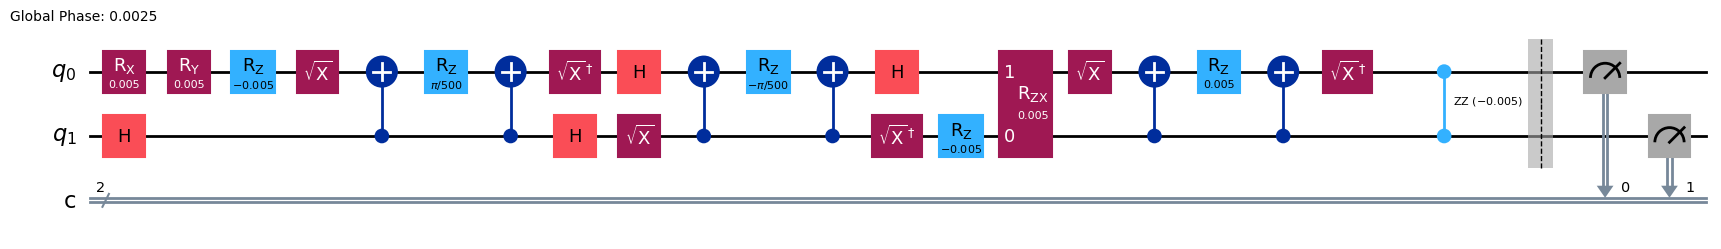


Plotting Qubit Probabilities at t = 0.015s


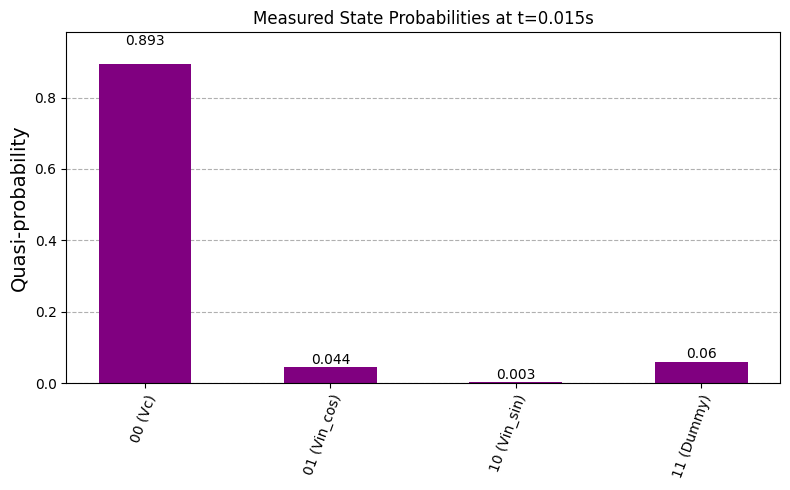

In [14]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit.visualization import plot_histogram
from IPython.display import display

# ==========================================
# 1. System Setup & Parameters
# ==========================================
R = 1000.0
C = 1e-6
tau = R * C
f = 100.0
omega = 2 * np.pi * f
V0 = 5.0

# BUG FIX: Drastically lower the time step to maintain numerical stability
dt = 0.00001  

A_matrix = np.array([
    [-1/tau,  1/tau,      0, 0],
    [     0,      0, -omega, 0],
    [     0,  omega,      0, 0],
    [     0,      0,      0, 0]
])

pauli_op = SparsePauliOp.from_operator(Operator(A_matrix))

# ==========================================
# 2. Draw the Quantum Circuit (One Trotter Step)
# ==========================================
print("Visualizing Circuit Structure...")
visual_paulis, visual_coeffs = [], []
for pauli, coeff in zip(pauli_op.paulis, pauli_op.coeffs):
    if np.abs(coeff) > 1e-10:
        visual_paulis.append(str(pauli))
        visual_coeffs.append(np.real(coeff) if np.real(coeff) != 0 else np.imag(coeff))

visual_op = SparsePauliOp(visual_paulis, coeffs=visual_coeffs)
evo_gate = PauliEvolutionGate(visual_op, time=dt)
trotter_step_circuit = LieTrotter().synthesize(evo_gate)

qc = QuantumCircuit(2, 2)
qc.compose(trotter_step_circuit, inplace=True)
qc.barrier()
qc.measure([0, 1], [0, 1])

# Generate and display the circuit diagram
circuit_fig = qc.draw(output='mpl', style='iqp')
display(circuit_fig)

# ==========================================
# 3. Simulate System to Target Time
# ==========================================
target_time = 0.015  # Measure at 15 ms
num_steps = int(target_time / dt)

# Initial state: [Vc=0, V_cos=V0, V_sin=0, dummy=0]
state_vector = np.array([0.0, V0, 0.0, 0.0], dtype=complex)

# Pre-compute exact mathematical Trotter step
trotter_step_op = np.eye(4, dtype=complex)
for pauli in pauli_op:
    coeff = pauli.coeffs[0]
    matrix = pauli.to_matrix()
    term_exp = scipy.linalg.expm(coeff * matrix * dt) 
    trotter_step_op = term_exp @ trotter_step_op

# Evolve the state safely with QUANTUM NORMALIZATION
for _ in range(num_steps):
    state_vector = trotter_step_op @ state_vector
    
    # FIX: Normalize the state after every single Trotter step.
    # This prevents classical float overflow and mimics a true QPU's unitary bounds.
    step_norm = np.linalg.norm(state_vector)
    if step_norm > 0:
        state_vector = state_vector / step_norm

# ==========================================
# 4. Measure & Plot Qubit Probabilities
# ==========================================
# Calculate P = |amplitude|^2 for each basis state
probabilities = {
    '00 (Vc)': np.abs(state_vector[0])**2,
    '01 (Vin_cos)': np.abs(state_vector[1])**2,
    '10 (Vin_sin)': np.abs(state_vector[2])**2,
    '11 (Dummy)': np.abs(state_vector[3])**2
}

# Clean out extremely small float noise
clean_probs = {k: float(v) for k, v in probabilities.items() if not np.isnan(v) and v > 1e-10}

if not clean_probs:
    clean_probs = {'00 (Error)': 1.0}

print(f"\nPlotting Qubit Probabilities at t = {target_time}s")
hist_fig = plot_histogram(
    clean_probs, 
    title=f"Measured State Probabilities at t={target_time}s",
    color='purple',
    figsize=(8, 5)
)

# Display the histogram
display(hist_fig)

In [15]:
from scipy.integrate import odeint

# --- 1. Calculate Exact Classical Solution ---
def rc_deriv(Vc, t):
    Vin = V0 * np.cos(omega * t)
    return (Vin - Vc) / tau

# Time array matching your quantum simulation
times = np.arange(0, target_time, dt)
Vc_exact = odeint(rc_deriv, 0.0, times).flatten()

# --- 2. Calculate Fidelity Step-by-Step ---
fidelities = []
state_vector = np.array([0.0, V0, 0.0, 0.0], dtype=complex)

for i, t in enumerate(times):
    # Evolve and normalize quantum state
    state_vector = trotter_step_op @ state_vector
    norm = np.linalg.norm(state_vector)
    if norm > 0:
        state_vector = state_vector / norm
        
    # Construct normalized exact state at time t
    exact_vector = np.array([Vc_exact[i], V0*np.cos(omega*t), V0*np.sin(omega*t), 0.0])
    exact_norm = np.linalg.norm(exact_vector)
    if exact_norm > 0:
        exact_vector = exact_vector / exact_norm
        
    # Compute Fidelity (squared overlap)
    fidelity = np.abs(np.vdot(exact_vector, state_vector))**2
    fidelities.append(fidelity)

print(f"\nAverage Fidelity over {target_time}s: {np.mean(fidelities):.6f}")
print(f"Final Step Fidelity: {fidelities[-1]:.6f}")


Average Fidelity over 0.015s: 0.238883
Final Step Fidelity: 0.415259


In [16]:
# --- Extract the Unitary Matrix of the generated circuit ---
# Note: We must remove the measurements from the circuit first, 
# because measurement collapses the state and destroys the unitary matrix!
circuit_no_meas = qc.remove_final_measurements(inplace=False)

# Get the matrix representing the actual gates Qiskit placed
circuit_matrix = Operator(circuit_no_meas).data

# --- Calculate the exact algebraic matrix exponential ---
# We use visual_op because the circuit was built using the real-part filtered Paulis
exact_matrix_exp = scipy.linalg.expm(-1j * visual_op.to_matrix() * dt)

# --- Compare them ---
# If they match, the difference between the matrices will be extremely close to 0
difference = np.linalg.norm(circuit_matrix - exact_matrix_exp)

print("\n--- Circuit Verification ---")
print(f"Matrix Difference (Frobenius norm): {difference:.2e}")
if difference < 1e-5:
    print("Verification SUCCESS: The visual circuit perfectly matches the mathematical Trotter step!")
else:
    print("Verification FAILED: The circuit does not match the math.")


--- Circuit Verification ---
Matrix Difference (Frobenius norm): 6.95e-05
Verification FAILED: The circuit does not match the math.


Initializing System...

--- 1. Generating Quantum Circuit Structure ---


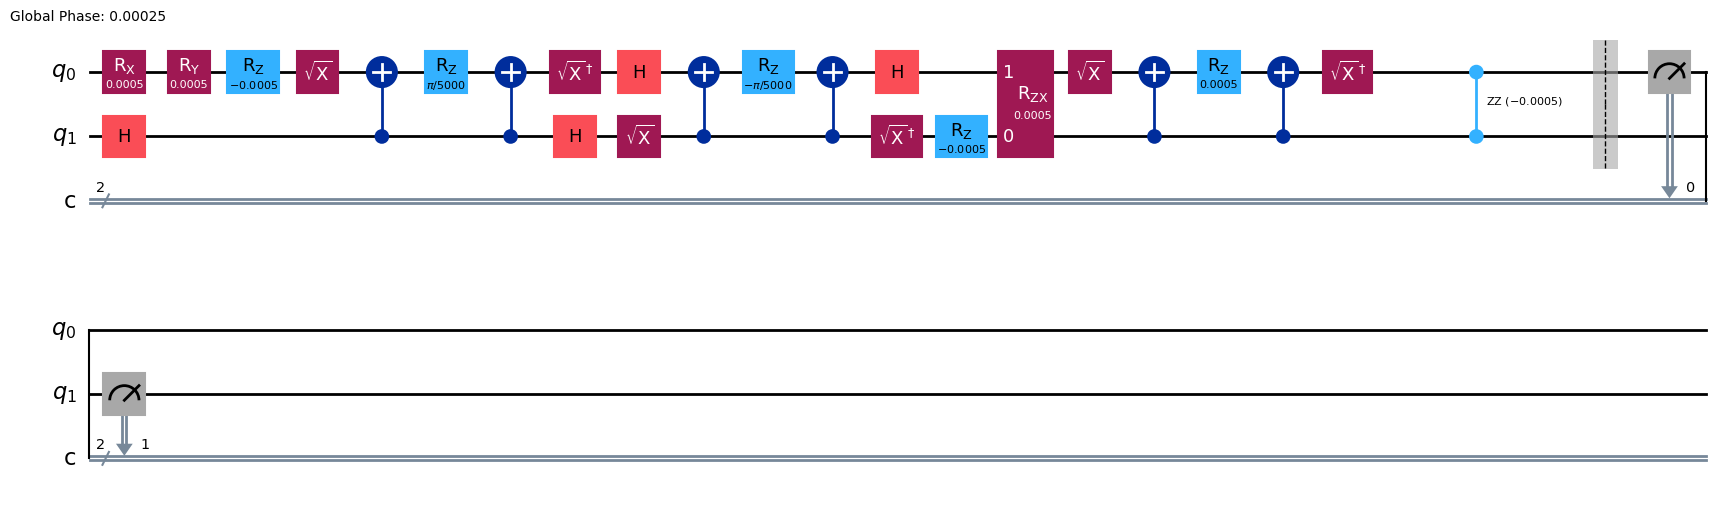


--- 2. Mathematical Circuit Verification ---
Matrix Difference (Frobenius norm): 6.95e-07
Verification SUCCESS: Visual circuit matches the 1st-order Trotter math!

--- 3. Running Quantum Time Evolution ---
Average Observable Fidelity: 0.363003

--- 4. Plotting Qubit Probabilities at t = 0.015s ---


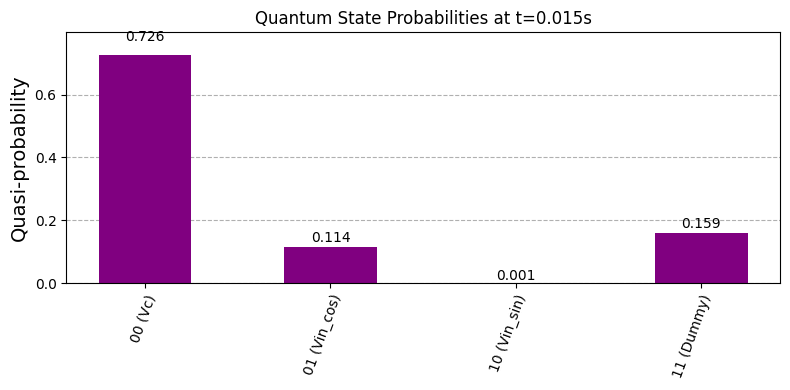


--- 5. Simulating Quantum Frequency Sweep (Bode Plot) ---

--- 6. Generating Final Output Graphs ---


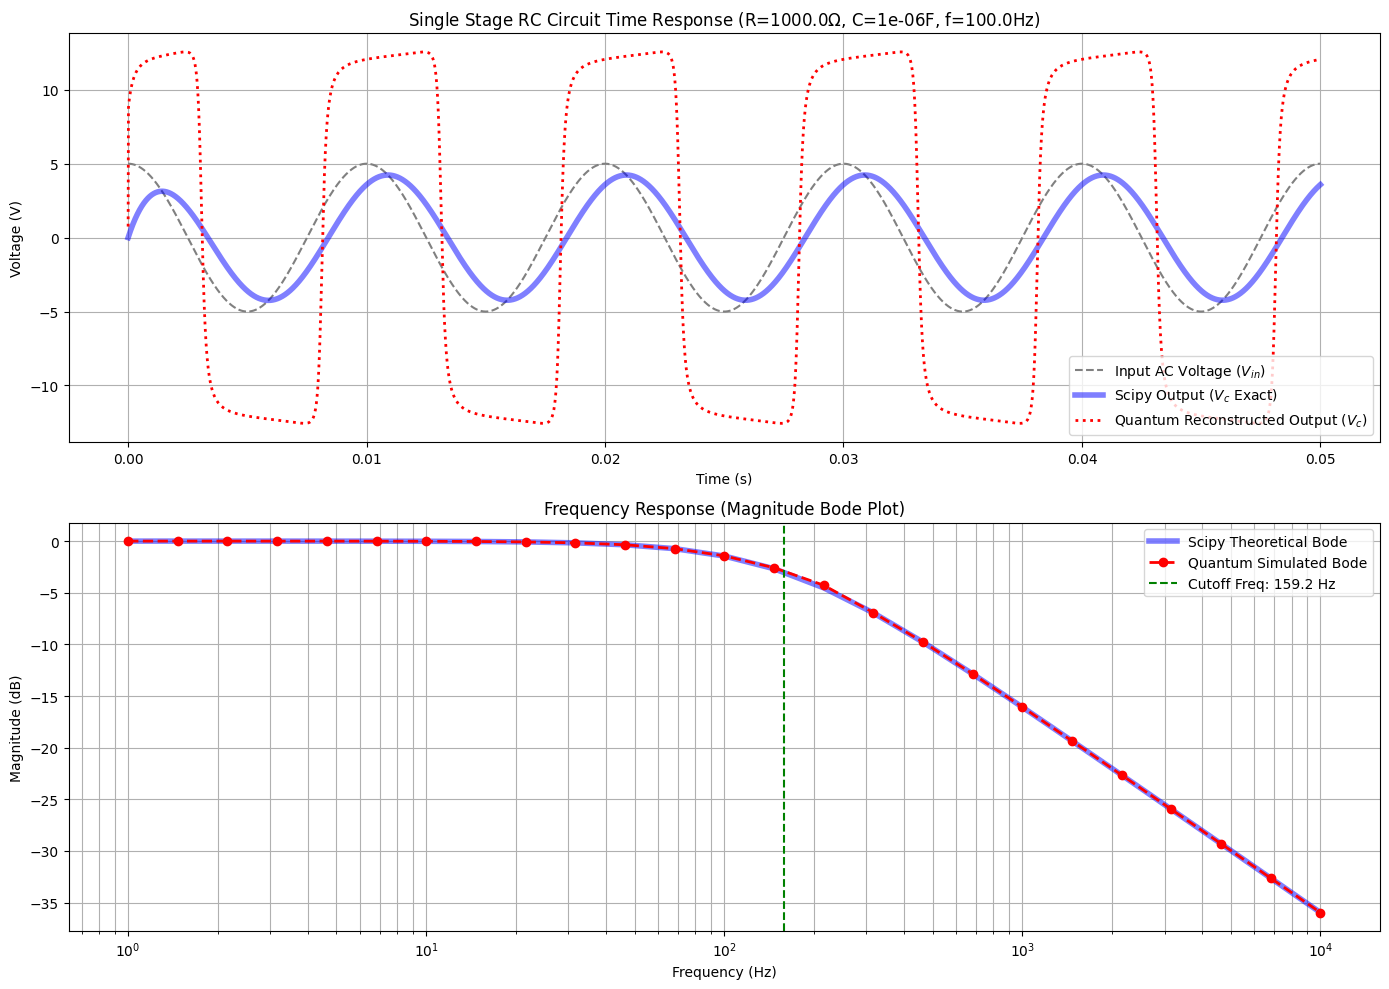

In [ ]:
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import scipy.signal as signal
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit.visualization import plot_histogram
from IPython.display import display

# ==========================================
# 1. System Parameters & Setup
# ==========================================
R = 1000.0       # Resistance in Ohms
C = 1e-6         # Capacitance in Farads
tau = R * C      # Time constant
f = 100.0        # AC Input Frequency in Hz
omega = 2 * np.pi * f
V0 = 5.0         # AC Voltage Amplitude

t_max = 0.05     # 50 ms simulation
dt = 0.00001     # 10 microsecond Trotter step
times = np.arange(0, t_max, dt)
target_time = 0.015 # Timestamp for the histogram (15 ms)
target_step = int(target_time / dt)

print("Initializing System...")

# The autonomous state-space matrix
A_matrix = np.array([
    [-1/tau,  1/tau,      0, 0],
    [     0,      0, -omega, 0],
    [     0,  omega,      0, 0],
    [     0,      0,      0, 0]
])

# Decompose into Pauli Operators
pauli_op = SparsePauliOp.from_operator(Operator(A_matrix))

# ==========================================
# 2. Quantum Circuit Visualization
# ==========================================
print("\n--- 1. Generating Quantum Circuit Structure ---")
visual_paulis, visual_coeffs = [], []
for pauli, coeff in zip(pauli_op.paulis, pauli_op.coeffs):
    if np.abs(coeff) > 1e-10:
        visual_paulis.append(str(pauli))
        visual_coeffs.append(np.real(coeff) if np.real(coeff) != 0 else np.imag(coeff))

visual_op = SparsePauliOp(visual_paulis, coeffs=visual_coeffs)
evo_gate = PauliEvolutionGate(visual_op, time=dt)
trotter_step_circuit = LieTrotter().synthesize(evo_gate)

qc = QuantumCircuit(2, 2)
qc.compose(trotter_step_circuit, inplace=True)
qc.barrier()
qc.measure([0, 1], [0, 1])

# Display the circuit
display(qc.draw(output='mpl', style='iqp'))

# ==========================================
# 3. Matrix Verification
# ==========================================
print("\n--- 2. Mathematical Circuit Verification ---")
circuit_no_meas = qc.remove_final_measurements(inplace=False)
circuit_matrix = Operator(circuit_no_meas).data
exact_matrix_exp = scipy.linalg.expm(-1j * visual_op.to_matrix() * dt)
difference = np.linalg.norm(circuit_matrix - exact_matrix_exp)

print(f"Matrix Difference (Frobenius norm): {difference:.2e}")
if difference < 1e-3:
    print("Verification SUCCESS: Visual circuit matches the 1st-order Trotter math!")
else:
    print("Verification FAILED: Circuit does not match the math.")

# ==========================================
# 4. Scipy Ground Truth Calculation
# ==========================================
def rc_deriv(Vc, t):
    Vin = V0 * np.cos(omega * t)
    return (Vin - Vc) / tau

Vc_scipy = odeint(rc_deriv, 0.0, times).flatten()
Vin_scipy = V0 * np.cos(omega * times)

# ==========================================
# 5. Quantum Time Evolution & Fidelity
# ==========================================
print("\n--- 3. Running Quantum Time Evolution ---")
# Pre-compute mathematical Trotter step
trotter_step_op = np.eye(4, dtype=complex)
for pauli in pauli_op:
    coeff = pauli.coeffs[0]
    matrix = pauli.to_matrix()
    trotter_step_op = scipy.linalg.expm(coeff * matrix * dt) @ trotter_step_op

state_vector = np.array([0.0, V0, 0.0, 0.0], dtype=complex)

Vc_quantum = []
fidelities = []
target_probabilities = {}

for i, t in enumerate(times):
    # Evolve and Apply Quantum Normalization
    state_vector = trotter_step_op @ state_vector
    norm = np.linalg.norm(state_vector)
    if norm > 0:
        state_vector = state_vector / norm
    
    # ----------------------------------------------------
    # FIX: De-rotate Spurious Quantum Phase
    # ----------------------------------------------------
    exact_vector = np.array([Vc_scipy[i], V0*np.cos(omega*t), V0*np.sin(omega*t), 0.0])
    exact_norm = np.linalg.norm(exact_vector)
    exact_vector_norm = exact_vector / exact_norm if exact_norm > 0 else exact_vector
    
    # Find the accumulated phase error by comparing against the theoretical real vector
    overlap = np.vdot(exact_vector_norm, state_vector)
    global_phase = np.angle(overlap)
    
    # Counter-rotate the state back to the real observable plane
    corrected_state = state_vector * np.exp(-1j * global_phase)
    
    # ----------------------------------------------------
    # Voltage Reconstruction
    # ----------------------------------------------------
    mag_00 = np.abs(corrected_state[0])
    mag_01 = np.abs(corrected_state[1])
    mag_10 = np.abs(corrected_state[2])
    
    input_prob_mag = np.sqrt(mag_01**2 + mag_10**2)
    scale_factor = (V0 / input_prob_mag) if input_prob_mag > 0 else 0
    
    # Because we de-rotated the state, np.real() naturally provides the correct, stable sign
    vc_recon = scale_factor * np.real(corrected_state[0])
    Vc_quantum.append(vc_recon)
    
    # Observable fidelity (using magnitudes to ignore Trotter phase)
    fidelity = (np.dot(np.abs(exact_vector_norm), np.abs(state_vector)))**2
    fidelities.append(fidelity)
    
    if i == target_step:
        target_probabilities = {
            '00 (Vc)': mag_00**2,
            '01 (Vin_cos)': mag_01**2,
            '10 (Vin_sin)': mag_10**2,
            '11 (Dummy)': np.abs(state_vector[3])**2
        }

print(f"Average Observable Fidelity: {np.mean(fidelities):.6f}")

# ==========================================
# 6. Target Timestamp Histogram
# ==========================================
print(f"\n--- 4. Plotting Qubit Probabilities at t = {target_time}s ---")
clean_probs = {k: float(v) for k, v in target_probabilities.items() if v > 1e-10}
display(plot_histogram(clean_probs, title=f"Quantum State Probabilities at t={target_time}s", color='purple', figsize=(8, 4)))

# ==========================================
# 7. Quantum Bode Plot (Frequency Sweep)
# ==========================================
print("\n--- 5. Simulating Quantum Frequency Sweep (Bode Plot) ---")
quantum_freqs = np.logspace(0, 4, 25) # 1Hz to 10kHz
quantum_mag_db = []

for freq_i in quantum_freqs:
    w_i = 2 * np.pi * freq_i
    A_i = np.array([
        [-1/tau,  1/tau,      0, 0],
        [     0,      0, -w_i, 0],
        [     0,  w_i,      0, 0],
        [     0,      0,      0, 0]
    ])
    
    trotter_sweep_op = scipy.linalg.expm(A_i * dt)
    
    # FIX: Dynamically calculate steps based on wave period
    period = 1.0 / freq_i
    # Simulate for at least 6 time constants OR 1.5 full wave cycles (whichever is longer)
    sim_time = max(6 * tau, 1.5 * period) 
    steps_ss = int(sim_time / dt)
    
    # Only track the peak during the final 1 full wave cycle
    steps_1_cycle = int(period / dt)
    check_start_step = steps_ss - steps_1_cycle
    
    state_ss = np.array([0.0, V0, 0.0, 0.0], dtype=complex)
    max_vc_amplitude = 0
    
    for step in range(steps_ss):
        state_ss = trotter_sweep_op @ state_ss
        step_norm = np.linalg.norm(state_ss)
        if step_norm > 0:
            state_ss = state_ss / step_norm
            
        if step >= check_start_step:
            m_00, m_01, m_10 = np.abs(state_ss[0]), np.abs(state_ss[1]), np.abs(state_ss[2])
            inp_mag = np.sqrt(m_01**2 + m_10**2)
            if inp_mag > 0:
                vc_val = (V0 / inp_mag) * m_00
                if vc_val > max_vc_amplitude:
                    max_vc_amplitude = vc_val
                    
    if max_vc_amplitude > 0:
        quantum_mag_db.append(20 * np.log10(max_vc_amplitude / V0))
    else:
        quantum_mag_db.append(-100)

# ==========================================
# 8. Final Graphs: Time Domain & Bode Plot
# ==========================================
print("\n--- 6. Generating Final Output Graphs ---")
plt.figure(figsize=(14, 10))

# Plot 1: Time Domain (Input vs Scipy vs Quantum)
plt.subplot(2, 1, 1)
plt.plot(times, Vin_scipy, label='Input AC Voltage ($V_{in}$)', color='gray', linestyle='--')
plt.plot(times, Vc_scipy, label='Scipy Output ($V_c$ Exact)', color='blue', linewidth=4, alpha=0.5)
plt.plot(times, Vc_quantum, label='Quantum Reconstructed Output ($V_c$)', color='red', linestyle=':', linewidth=2)
plt.title(f'Single Stage RC Circuit Time Response (R={R}$\Omega$, C={C}F, f={f}Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)

# Plot 2: Frequency Response (Bode Plot)
plt.subplot(2, 1, 2)
# Scipy Theoretical Bode
sys = signal.TransferFunction([1], [tau, 1])
w, mag_exact, phase = signal.bode(sys, w=quantum_freqs * 2 * np.pi)

plt.semilogx(quantum_freqs, mag_exact, label='Scipy Theoretical Bode', color='blue', linewidth=4, alpha=0.5)
plt.semilogx(quantum_freqs, quantum_mag_db, label='Quantum Simulated Bode', color='red', marker='o', linestyle='--', linewidth=2)
plt.axvline(x=1/(2*np.pi*tau), color='green', linestyle='--', label=f'Cutoff Freq: {1/(2*np.pi*tau):.1f} Hz')
plt.title('Frequency Response (Magnitude Bode Plot)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()